# Linear Regression

Linear Regression dùng một đường thẳng để đoán một con số liên tục, ví dụ doanh thu, giá nhà, hoặc thời gian đi đến nơi.

Bài này đi theo cửa hàng Starbucks ở London. Đọc từ trên xuống. Mỗi phần là một bước: bắt đầu từ đường thẳng nằm ở 0, rồi sai số nhỏ dần.


## 1. Bài toán Starbucks London

Cửa hàng mở càng nhiều giờ thì doanh thu một ngày càng cao. Ta dùng số giờ mở cửa để đoán doanh thu.

### Dữ liệu

| Features | Label | Predict |
| --- | --- | --- |
| #Operating Hours (hours) | #Daily Sales (USD) |  |
| 5 | 600 | 0 |
| 7 | 790 | 0 |
| 9 | 900 | 0 |

- Features là số giờ mở cửa.
- Label là doanh thu thật, tính bằng USD.
- Predict là doanh thu mô hình đoán. Lúc mới bắt đầu, cả ba dòng đều đoán 0.

Ba điểm thật là (5, 600), (7, 790) và (9, 900). Trục ngang là số giờ. Trục dọc là doanh thu.

### Đường thẳng lúc bắt đầu

$$Y = w_1 X + w_0$$

- weight, ký hiệu w1, là độ dốc của đường.
- bias, ký hiệu w0, là doanh thu đoán được khi số giờ bằng 0.

Lúc đầu cả hai số đều bằng 0, nên mọi dự đoán đều bằng 0:

$$\hat{Y} = 0 \times X + 0 = 0$$

Đường nằm trên trục ngang, xa cả ba điểm doanh thu.

### Hàm mất mát

Hàm mất mát cho biết dự đoán lệch doanh thu thật bao nhiêu. Bài này dùng MSE: bình phương từng sai số, cộng lại, rồi chia cho 3 cửa hàng.

$$MSE = \frac{(600 - 0)^2 + (790 - 0)^2 + (900 - 0)^2}{3} = 598033$$

MSE càng nhỏ thì đường càng sát dữ liệu. 598033 còn rất lớn, nên mô hình phải đổi weight và bias.

### Sau một vòng học

Slide ghi hai hệ số mới:

- bias w1 = 75
- weight w0 = 238

Dự đoán mới là 500, 720 và 890.

| Giờ | Doanh thu thật | Dự đoán | Sai số |
| --- | --- | --- | --- |
| 5 | 600 | 500 | 100 |
| 7 | 790 | 720 | 70 |
| 9 | 900 | 890 | 10 |

$$MSE = \frac{100^2 + 70^2 + 10^2}{3} = \frac{10000 + 4900 + 100}{3} = 5000$$

MSE giảm từ 598033 xuống 5000. Đường đã lên gần các điểm. Ô code bên dưới vẽ hình này: chấm xanh là doanh thu thật, đường vàng là dự đoán, đoạn thẳng đứng là sai số 100, 70 và 10.


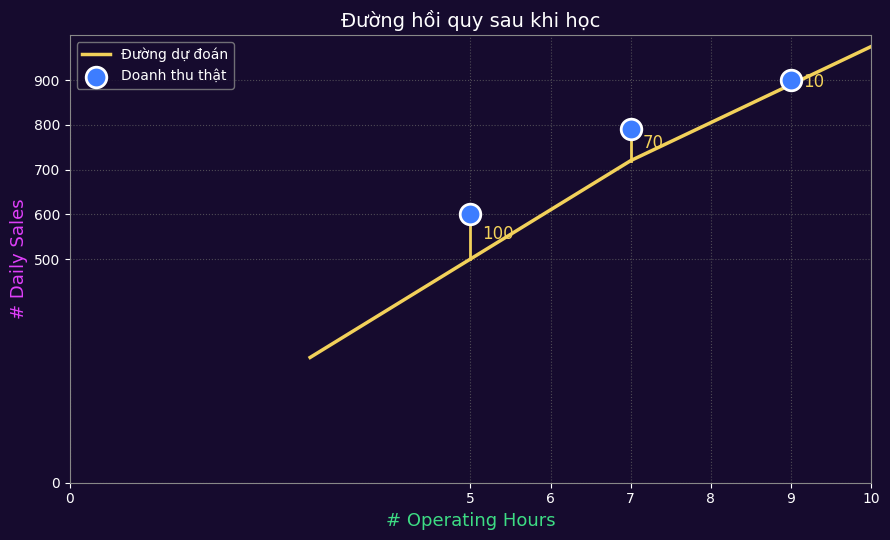

In [34]:
import matplotlib.pyplot as plt
import numpy as np

hours = np.array([5, 7, 9])
actual = np.array([600, 790, 900])
predict = np.array([500, 720, 890])

slope_left = (predict[1] - predict[0]) / (hours[1] - hours[0])
slope_right = (predict[2] - predict[1]) / (hours[2] - hours[1])
x_line = np.array([3, 5, 7, 9, 10])
y_line = np.array([
    predict[0] - slope_left * (hours[0] - 3),
    predict[0],
    predict[1],
    predict[2],
    predict[2] + slope_right * (10 - hours[2]),
])

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#160b2e")
ax.set_facecolor("#160b2e")

ax.plot(x_line, y_line, color="#f2d15a", linewidth=2.5, zorder=2, label="Đường dự đoán")

for x, y, yhat in zip(hours, actual, predict):
    ax.plot([x, x], [yhat, y], color="#f2d15a", linewidth=2, zorder=3)
    ax.text(
        x + 0.15,
        yhat + (y - yhat) * 0.55,
        str(int(y - yhat)),
        color="#f2d15a",
        fontsize=12,
        va="center",
    )

ax.scatter(
    hours,
    actual,
    s=220,
    c="#3d7dff",
    edgecolors="white",
    linewidths=2,
    zorder=4,
    label="Doanh thu thật",
)

ax.set_xlim(0, 10)
ax.set_ylim(0, 1000)
ax.set_xticks([0, 5, 6, 7, 8, 9, 10])
ax.set_yticks([0, 500, 600, 700, 800, 900])
ax.set_xlabel("# Operating Hours", color="#3ddc84", fontsize=13)
ax.set_ylabel("# Daily Sales", color="#e040fb", fontsize=13)
ax.tick_params(colors="white")
ax.set_title("Đường hồi quy sau khi học", color="white", fontsize=14)
for spine in ax.spines.values():
    spine.set_color("#888888")
ax.grid(True, linestyle=":", color="#666666", alpha=0.7)
legend = ax.legend(facecolor="#160b2e", edgecolor="#888888", loc="upper left")
for text in legend.get_texts():
    text.set_color("white")

fig.tight_layout()
plt.show()

## 2. Gradient Descent

1. Chọn weight và bias.
2. Vẽ đường hồi quy.
3. Tính mất mát trên dữ liệu.
4. Kiểm tra sai số.
5. Nếu sai số còn lớn, lặp lại để tìm sai số nhỏ hơn.

Ba lần kiểm tra trong bài Starbucks:

| Vòng | Hệ số trên slide | MSE |
| --- | --- | --- |
| Bắt đầu | weight = 0, bias = 0 | 598033 |
| Vòng giữa | bias w1 = 75, weight w0 = 238 | 5000 |
| Vòng nhỏ nhất | bias w1 = 70, weight w0 = 200 | 133 |

598033 còn rất lớn nên vòng lặp chạy tiếp. 5000 đã nhỏ hơn nhiều. 133 là sai số nhỏ nhất trong ba lần.

Ở vòng nhỏ nhất, dự đoán gần như trùng doanh thu thật:

| Giờ | Doanh thu thật | Dự đoán | Sai số |
| --- | --- | --- | --- |
| 5 | 600 | 600 | 0 |
| 7 | 790 | 770 | 20 |
| 9 | 900 | 900 | 0 |

$$MSE = \frac{0^2 + 20^2 + 0^2}{3} = \frac{400}{3} \approx 133$$

Đường đi qua đúng mốc 5 giờ và 9 giờ. Chỉ còn lệch 20 USD ở mốc 7 giờ. Ô code bên dưới vẽ đường này.


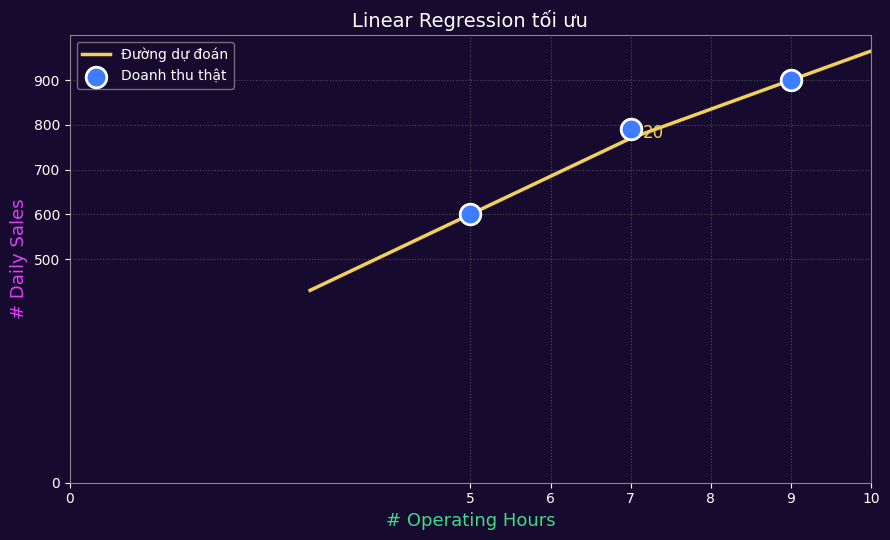

In [35]:
import matplotlib.pyplot as plt
import numpy as np

hours = np.array([5, 7, 9])
actual = np.array([600, 790, 900])
predict = np.array([600, 770, 900])

slope_left = (predict[1] - predict[0]) / (hours[1] - hours[0])
slope_right = (predict[2] - predict[1]) / (hours[2] - hours[1])
x_line = np.array([3, 5, 7, 9, 10])
y_line = np.array([
    predict[0] - slope_left * (hours[0] - 3),
    predict[0],
    predict[1],
    predict[2],
    predict[2] + slope_right * (10 - hours[2]),
])

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#160b2e")
ax.set_facecolor("#160b2e")

ax.plot(x_line, y_line, color="#f2d15a", linewidth=2.5, zorder=2, label="Đường dự đoán")

for x, y, yhat in zip(hours, actual, predict):
    if y != yhat:
        ax.plot([x, x], [yhat, y], color="#f2d15a", linewidth=2, zorder=3)
        ax.text(
            x + 0.15,
            yhat + (y - yhat) * 0.55,
            str(int(y - yhat)),
            color="#f2d15a",
            fontsize=12,
            va="center",
        )

ax.scatter(
    hours,
    actual,
    s=220,
    c="#3d7dff",
    edgecolors="white",
    linewidths=2,
    zorder=4,
    label="Doanh thu thật",
)

ax.set_xlim(0, 10)
ax.set_ylim(0, 1000)
ax.set_xticks([0, 5, 6, 7, 8, 9, 10])
ax.set_yticks([0, 500, 600, 700, 800, 900])
ax.set_xlabel("# Operating Hours", color="#3ddc84", fontsize=13)
ax.set_ylabel("# Daily Sales", color="#e040fb", fontsize=13)
ax.tick_params(colors="white")
ax.set_title("Linear Regression tối ưu", color="white", fontsize=14)
for spine in ax.spines.values():
    spine.set_color("#888888")
ax.grid(True, linestyle=":", color="#666666", alpha=0.7)
legend = ax.legend(facecolor="#160b2e", edgecolor="#888888", loc="upper left")
for text in legend.get_texts():
    text.set_color("white")

fig.tight_layout()
plt.show()

## 3. Chạy 1 lần dự đoán

Công thức đọc từ trái sang phải:

$$\text{Predict} = \text{weight} \times \text{Features} + \text{bias}$$

$$\text{Loss} = \text{Predict} - \text{Label}$$

Ô code bên dưới chỉ tính một lần, với weight = 1 và bias = 1.

- Predict = 1 nhân [5, 7, 9] rồi cộng 1, ra [6, 8, 10]
- Loss = Predict trừ Label, ra [-594, -782, -890]

Mô hình đoán doanh thu quanh 6, 8 và 10 USD, trong khi doanh thu thật là 600, 790 và 900. Loss âm vì đoán thấp hơn thật rất nhiều. Sai số còn cao, nên cần huấn luyện.


In [43]:
# weight = 1 và bias = 1, chỉ tính Predict và Loss một lần.
import numpy as np

weight = 1
bias = 1

features = np.array([5, 7, 9])
label = np.array([600, 790, 900])
predictions = weight * features + bias
error = predictions - label
mse = np.mean(error ** 2)
print("Predictions:", predictions)
print("Error:", error)
print(f"Sai số vẫn còn rất cao MSE = {mse:.2f}")
print("Chạy 1 lần để dự đoán không hiệu quả")

Predictions: [ 6  8 10]
Error: [-594 -782 -890]
Sai số vẫn còn rất cao MSE = 585486.67
Chạy 1 lần để dự đoán không hiệu quả


## 4. Model training

Huấn luyện là lặp lại việc dự đoán nhiều vòng, mỗi vòng chỉnh weight và bias.

Ô code bắt đầu từ weight = 0 và bias = 0. Nó lặp 1000 vòng, learning rate = 0.01. Mỗi vòng làm bốn việc:

1. Tính Predict = weight nhân Features, rồi cộng bias.
2. Tính Loss = Predict trừ Label.
3. Tính độ dốc của weight và của bias.
4. Chỉnh hai hệ số đi ngược độ dốc, để sai số giảm.

Learning rate là độ dài của một bước. Số 0.01 là một bước ngắn.


## 5. Training model (mual)

Độ dốc của MSE:

$$\frac{\partial MSE}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot x_i$$

$$\frac{\partial MSE}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)$$

Mỗi vòng, weight và bias được cập nhật bằng:

$$w = w - \alpha \cdot \frac{\partial MSE}{\partial w}$$

$$b = b - \alpha \cdot \frac{\partial MSE}{\partial b}$$

- Alpha là learning rate. 


In [37]:
import numpy as np

features = np.array([5, 7, 9])
labels = np.array([600, 790, 900])

weight = 0.0
bias = 0.0

learning_rate = 0.01 # tỷ lệ học
epochs = 1000 # số lần lặp của mô hình


n = len(features)

# Gradient Descent Loop
for i in range(epochs):
    predictions = weight * features + bias
    error = predictions - labels

    weight_grad = (2/n) * np.dot(error, features)
    bias_grad = (2/n) * np.sum(error)
    weight -= learning_rate * weight_grad
    bias -= learning_rate * bias_grad


print(f"Final weight: {weight:.4f}")
print(f"Final bias: {bias:.4f}")

Final weight: 86.0206
Final bias: 157.0709


## 6. Training model (thư viện)

Cùng dữ liệu giờ mở cửa và doanh thu. Lần này không tự viết công thức cập nhật. Thư viện scikit-learn tự tìm weight và bias của đường khít nhất.

features phải là bảng hai chiều: mỗi dòng là một cửa hàng, mỗi cột là một đặc trưng. Vì chỉ có một đặc trưng là số giờ, ta dùng reshape để biến [5, 7, 9] thành một cột.


In [38]:
import numpy as np
from sklearn.linear_model import LinearRegression

features = np.array([5, 7, 9]).reshape(-1, 1)
labels = np.array([600, 790, 900])

model = LinearRegression()
model.fit(features, labels)

print(f"Final weight: {model.coef_[0]:.4f}")
print(f"Final bias: {model.intercept_:.4f}")
print("Predictions:", model.predict(features))

Final weight: 75.0000
Final bias: 238.3333
Predictions: [613.33333333 763.33333333 913.33333333]


## 7. Gradient Descent

Bốn ý cần giữ:

- Gradient Descent là vòng lặp chỉnh weight và bias để MSE nhỏ dần.
- Mỗi lần cập nhật là một bước chân. Learning rate quyết định bước dài hay ngắn. Bước quá lớn thì nhảy qua đáy. Bước quá nhỏ thì học rất chậm.
- Mô hình tự đi, không cần thử hệ số bằng tay. 
- Một vòng gồm: chọn hệ số, tính Predict, tính MSE, kiểm tra sai số, rồi cập nhật:

$$w = w - \alpha \cdot \frac{\partial MSE}{\partial w}$$

$$b = b - \alpha \cdot \frac{\partial MSE}{\partial b}$$

Rồi lặp lại cho đến khi sai số nhỏ.


## Vd2


$$F(x) = x^2 + 5\sin(x)$$

Bắt đầu ở nhánh bên phải:

- x bắt đầu bằng 5
- learning rate bằng 0.1
- Iteration = 0, cost = 20.21

Iteration là số vòng mô hình đã học. Iteration = 0 nghĩa là chưa bước lần nào. Điểm đỏ đang đứng ở x = 5, cost = 20.21.

Điểm vàng là cực tiểu, cũng là điểm tốt nhất của hàm này, vì cost ở đó thấp nhất: x khoảng -1.11, cost khoảng -3.25. Học thành công khi các bước dừng ở điểm vàng.


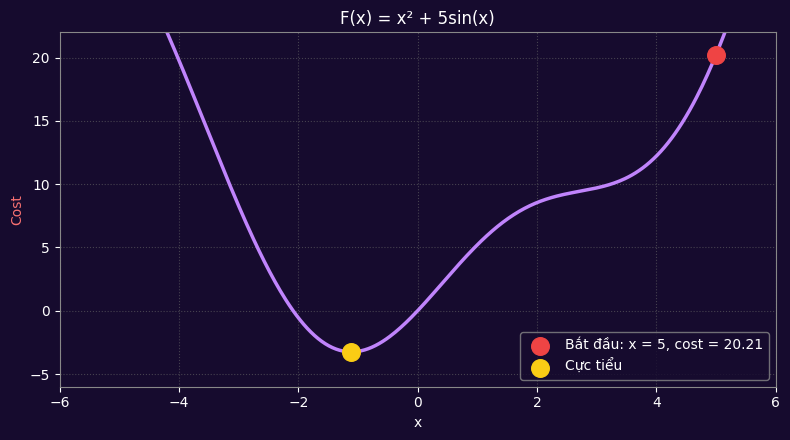

In [39]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 400)
cost = x**2 + 5 * np.sin(x)

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor("#160b2e")
ax.set_facecolor("#160b2e")

ax.plot(x, cost, color="#c084fc", linewidth=2.5)
ax.scatter([5], [20.21], s=160, c="#ef4444", zorder=3, label="Bắt đầu: x = 5, cost = 20.21")
ax.scatter([-1.11], [-3.25], s=160, c="#facc15", zorder=3, label="Cực tiểu")

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 22)
ax.set_xlabel("x", color="white")
ax.set_ylabel("Cost", color="#f87171")
ax.tick_params(colors="white")
ax.set_title("F(x) = x² + 5sin(x)", color="white")
for spine in ax.spines.values():
    spine.set_color("#888888")
ax.grid(True, linestyle=":", color="#666666", alpha=0.6)
legend = ax.legend(facecolor="#160b2e", edgecolor="#888888")
for text in legend.get_texts():
    text.set_color("white")
fig.tight_layout()
plt.show()

In [40]:
import numpy as np

def cost(x):
    return x**2 + 5 * np.sin(x)

def gradient(x):
    return 2 * x + 5 * np.cos(x)

x = 5.0
learning_rate = 0.1
current_cost = cost(x)

print(f"Iteration = 0, x = {x:.4f}, cost = {current_cost:.2f}")

for iteration in range(1, 101):
    x = x - learning_rate * gradient(x)
    new_cost = cost(x)
    change = new_cost - current_cost
    print(
        f"Iteration = {iteration}, x = {x:.4f}, cost = {new_cost:.4f}, change = {change:.4f}"
    )
    if abs(change) < 1e-4:
        print(f"Dừng tại cực tiểu: x = {x:.4f}, cost = {new_cost:.4f}")
        break
    current_cost = new_cost

Iteration = 0, x = 5.0000, cost = 20.21
Iteration = 1, x = 3.8582, cost = 11.6014, change = -8.6039
Iteration = 2, x = 3.4636, cost = 10.4141, change = -1.1873
Iteration = 3, x = 3.2452, cost = 10.0141, change = -0.3999
Iteration = 4, x = 3.0934, cost = 9.8101, change = -0.2041
Iteration = 5, x = 2.9742, cost = 9.6789, change = -0.1311
Iteration = 6, x = 2.8724, cost = 9.5804, change = -0.0985
Iteration = 7, x = 2.7799, cost = 9.4971, change = -0.0833
Iteration = 8, x = 2.6915, cost = 9.4195, change = -0.0777
Iteration = 9, x = 2.6034, cost = 9.3407, change = -0.0788
Iteration = 10, x = 2.5121, cost = 9.2543, change = -0.0864
Iteration = 11, x = 2.4138, cost = 9.1526, change = -0.1017
Iteration = 12, x = 2.3044, cost = 9.0241, change = -0.1285
Iteration = 13, x = 2.1783, cost = 8.8503, change = -0.1737
Iteration = 14, x = 2.0280, cost = 8.5993, change = -0.2511
Iteration = 15, x = 1.8432, cost = 8.2129, change = -0.3864
Iteration = 16, x = 1.6090, cost = 7.5853, change = -0.6276
Iterat

## Từ Iteration 3, mô hình học chậm

Ô code phía trên in từng vòng. Cột change là phần cost thay đổi so với vòng trước. Số âm nghĩa là cost đang giảm.

- Iteration 0: x = 5, cost = 20.21. Chưa học bước nào.
- Iteration 1: cost giảm khoảng 8.6. Bước còn dài vì đang ở nhánh dốc.
- Iteration 3: x khoảng 3.25, cost khoảng 10.01, cost chỉ giảm khoảng 0.40.
- Vài vòng sau đó, change chỉ còn khoảng -0.2 rồi -0.1.

Đó là đoạn gần như phẳng trên hình, chỗ điểm đỏ và điểm xanh nằm sát nhau. Gradient nhỏ, nên bước cập nhật cũng nhỏ:

$$x = x - 0.1 \times \text{gradient}$$

Mô hình la cà trên đoạn phẳng, cần nhiều vòng mới bò ra, rồi mới rơi nhanh xuống cực tiểu. Khi change về 0, cost không giảm thêm được nữa.
